In [2]:
# pip install autolrtuner
!pip install audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 15.1 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.0.0
    Uninstalling soxr-1.0.0:
      Successfully uninstalled soxr-1.0.0


# Set up library

In [3]:
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint,  EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import h5py
from sklearn.utils.class_weight import compute_class_weight
# from autolrtuner import AutoLRTuner
import os
from audiomentations import Compose, AddGaussianNoise, Gain





# Mount Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Agumentations

In [5]:
augment = Compose([

    # Noise Injection
    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.01,
        p=0.5
    ),

    # Random Gain
    Gain(
        min_gain_db=-6,
        max_gain_db=6,
        p=0.5
    )

])

#Data Module

In [6]:
from os.path import isfile
class DataModule:

    def __init__(self):
        self.data_set_dic = {}

    def __extract_dft(self, window):
        eps = 1e-10
        spectrum = np.abs(np.fft.rfft(window))
        spectrum = spectrum / np.max(spectrum + eps)
        return spectrum

    def __suppress_low_amplitudes(self, spec, threshold_db=50):
        I_threshold = 10 ** (-threshold_db / 20)
        spec[spec < I_threshold] *= 0.2
        return spec
    def __get_spectrum_of_window(self, window):

        spectrum = self.__extract_dft(window)

        #preprocessing
        standard_spectrum = self.__suppress_low_amplitudes(spectrum)

        return standard_spectrum
    def __get_spectrograms_and_labels_of_each_audio(self, audio, df, sample_rate, samples_per_window):

        X = []
        y = []


        # preparing data
        for _, row in df.iterrows():
            start_sample = int(row["start_time"] * sample_rate)
            end_sample = start_sample + samples_per_window

            if end_sample > len(audio):
                continue

            window = audio[start_sample:end_sample]
            spectrum = self.__get_spectrum_of_window(window)

            X.append(spectrum)
            y.append(row["label"])

        # reducing silence sample
        silence_label = "silence"
        flag = True
        start_index = 0
        end_index = len(y) - 1
        max_silence_label = 3
        X_reduced = []
        y_reduced = []
        while flag:
          if y[start_index] == silence_label:
                start_index += 1

          if y[end_index] == silence_label:
                end_index -= 1

          if y[start_index] != silence_label and y[end_index] != silence_label:
                X_reduced = X[start_index:end_index + 1]
                y_reduced = y[start_index:end_index + 1]


                num_start_silence = start_index - 0
                num_end_silence = len(y) - 1 - end_index

                if num_start_silence > max_silence_label:
                    num_start_silence = max_silence_label

                if num_end_silence > max_silence_label:
                    num_end_silence = max_silence_label

                for i in np.arange(num_start_silence):
                    X_reduced.append(X[i])
                    y_reduced.append(y[i])

                for i in np.arange(num_end_silence):
                    end_index = len(y) - 1 - i
                    X_reduced.append(X[end_index])
                    y_reduced.append(y[end_index])

                flag = False


        return np.array(X_reduced), np.array(y_reduced)


    def process_one_file_audio(
        self,
        audio_path,
        csv_path,
        sample_rate=48000,
        window_size=0.01
    ):

        #load audio
        audios = []
        audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
        audios.append(audio)

        #data augmentations
        quantities_au = 1
        for i in range(quantities_au):
            augmented_audio = augment(samples=audio, sample_rate=sr)
            audios.append(augmented_audio)

        samples_per_window = int(sample_rate * window_size)

        # Load CSV
        df = pd.read_csv(csv_path)
        X = []
        y = []

        # preparing data
        for audio in audios:
            X_temp, y_temp = self.__get_spectrograms_and_labels_of_each_audio(audio, df, sample_rate, samples_per_window)
            X.append(X_temp)
            y.append(y_temp)
        return X, y

    def build_dataset(self):

        # read data from drive
        audio_data_set_path = "/content/drive/MyDrive/Qeej_Hmong_Dataset/Data/audio"
        audio_folder_name = "audio"
        labels_folder_name = "labels"

        if os.path.exists(audio_data_set_path):
          for root, dirs, files in os.walk(audio_data_set_path):
            for file in files:
              if file.endswith(".wav"):
                audio_file_path = os.path.join(root, file)
                labels_file_name = file.replace(".wav", ".csv")
                labels_file_root = root.replace(audio_folder_name, labels_folder_name)
                #check if specified audio has corresponded labels file
                labels_path = os.path.join(labels_file_root, labels_file_name)
                # print("check audio path and labels path: ", audio_file_path, labels_path)
                if os.path.exists(labels_path):
                    if os.path.exists(labels_path):
                      self.data_set_dic[audio_file_path] = labels_path
                    else:
                      print(labels_path, "is not a file")
                else:
                  print("Cant find file at", labels_path)

        else:
          print("Cant find folder at /content/drive/MyDrive/Qeej_Hmong_Dataset/Data/audio")

        X_all = []
        y_all = []

        for audio_file_path, labels_file_path in self.data_set_dic.items():
          #  print ("check audio path and corresponding label path: ", audio_file_path, labels_file_path)
           X, y = self.process_one_file_audio(audio_file_path, labels_file_path)
           X_all.extend(X)
           y_all.extend(y)

        X_all = np.vstack(X_all)
        y_all = np.hstack(y_all)

        return X_all, y_all

#Main

## Set up HDF5 File and labeling Data

In [7]:
HDF5_file_path = "/content/drive/MyDrive/Qeej_Hmong_Dataset/HDF5"
X = None
y = None

if os.path.exists(HDF5_file_path):
    data_set_path = HDF5_file_path + "/Qeej_Hmong_Features.h5"
    if os.path.exists(data_set_path):
      print("Retrieving data from drive with path:", data_set_path)
      with h5py.File(data_set_path, "r") as f:
        X = f["features"][:]
        y = f["labels"][:]

    else:
        print("set up data")
        dataModule = DataModule()
        X, y = dataModule.build_dataset()
        print("check len X:", len(X))
        print("check len y:", len(y))
        with h5py.File(data_set_path, "w") as f:
          f.create_dataset("features", data=X)
          f.create_dataset("labels", data=y.tolist())

Retrieving data from drive with path: /content/drive/MyDrive/Qeej_Hmong_Dataset/HDF5/Qeej_Hmong_Features.h5


##label encoding

In [8]:
le = LabelEncoder()
y_int = le.fit_transform(y)
y_cat = to_categorical(y_int)

class_names = le.classes_

## Set up Training/Validation/Testing Data

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.3, stratify=y_int)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.1)

y_train_int = np.argmax(y_train, axis=1)
print("check y train int:", y_train_int)


check y train int: [19 47  6 ... 14 20 50]


## Set up Class Weights

In [10]:
unique, counts = np.unique(y_train_int, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))

print("check class weight dict:", class_weight_dict)


Class 0: 5891 samples
Class 1: 5232 samples
Class 2: 4729 samples
Class 3: 4416 samples
Class 4: 4602 samples
Class 5: 4073 samples
Class 6: 3930 samples
Class 7: 4329 samples
Class 8: 3909 samples
Class 9: 4361 samples
Class 10: 4878 samples
Class 11: 4599 samples
Class 12: 4089 samples
Class 13: 4504 samples
Class 14: 4386 samples
Class 15: 4194 samples
Class 16: 4448 samples
Class 17: 5223 samples
Class 18: 5037 samples
Class 19: 4427 samples
Class 20: 4152 samples
Class 21: 4526 samples
Class 22: 4329 samples
Class 23: 4211 samples
Class 24: 4183 samples
Class 25: 5320 samples
Class 26: 5004 samples
Class 27: 4487 samples
Class 28: 4845 samples
Class 29: 5459 samples
Class 30: 4332 samples
Class 31: 5062 samples
Class 32: 3566 samples
Class 33: 5604 samples
Class 34: 4879 samples
Class 35: 4312 samples
Class 36: 4416 samples
Class 37: 4246 samples
Class 38: 4243 samples
Class 39: 4031 samples
Class 40: 4430 samples
Class 41: 4361 samples
Class 42: 5027 samples
Class 43: 4297 sample

## Set up early stopping

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

## Set up check points

In [12]:
CHECKPOINT_DIR = "/content/drive/MyDrive/Qeej_Hmong_Model_Parameters/CheckPoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "model_latest.keras")

checkpoint_callback = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    save_weights_only=False,
    save_best_only=False,
    save_freq='epoch'
)

## set up model

In [13]:

batch_size = 512
epoch = 500


if os.path.exists(CHECKPOINT_PATH):
    print("Loading existing model...")
    model = load_model(CHECKPOINT_PATH)
    initial_epoch = int(model.optimizer.iterations.numpy() / (len(X_train) // batch_size))
else:
    print("Creating new model...")
    model = Sequential([
        Conv1D(32, kernel_size=5, activation='relu',
              input_shape=(X.shape[1], 1)),
        MaxPooling1D(2),
        Dropout(0.25),

        Conv1D(64, kernel_size=5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(y_cat.shape[1], activation='softmax')
    ])
    # model = Sequential([
    #     Conv1D(32, 5, activation='relu', input_shape=(X.shape[1],1)),
    #     BatchNormalization(),
    #     MaxPooling1D(2),
    #     Dropout(0.25),

    #     Conv1D(64, 5, activation='relu'),
    #     BatchNormalization(),
    #     MaxPooling1D(2),
    #     Dropout(0.25),

    #     Conv1D(128, 5, activation='relu'),
    #     BatchNormalization(),
    #     MaxPooling1D(2),
    #     Dropout(0.25),

    #     Flatten(),

    #     Dense(128, activation='relu'),
    #     Dropout(0.5),

    #     Dense(y_cat.shape[1], activation='softmax')
    # ])

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )
    initial_epoch = 0

    #lr finder
    # tuner = AutoLRTuner(model)
    # tuner.Tune(
    #     X_train,
    #     y_train,
    #     batch_size=batch_size,
    #     num_evals=200
    # )

    # best_lr = tuner.GetBestLR()

    # print("best learning rate for model:",best_lr)
    # tuner.Plot()



Creating new model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## training model

In [14]:

model.fit(
    X_train[..., np.newaxis],
    y_train,
    validation_data=(X_val[..., np.newaxis], y_val),
    class_weight=class_weight_dict,
    epochs=epoch,
    batch_size=batch_size,
    callbacks=[checkpoint_callback, early_stop],
    initial_epoch=initial_epoch
)



Epoch 1/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.0755 - loss: 3.8745 - val_accuracy: 0.2949 - val_loss: 2.8382
Epoch 2/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2199 - loss: 3.0552 - val_accuracy: 0.3997 - val_loss: 2.4321
Epoch 3/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2759 - loss: 2.7990 - val_accuracy: 0.4522 - val_loss: 2.1489
Epoch 4/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3070 - loss: 2.6550 - val_accuracy: 0.4887 - val_loss: 2.0177
Epoch 5/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3276 - loss: 2.5616 - val_accuracy: 0.5139 - val_loss: 1.9343
Epoch 6/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3431 - loss: 2.4893 - val_accuracy: 0.5326 - val_loss: 1.8597
Epoch 7/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3527 - loss: 2.4440 - val_accuracy: 0.5431 - val_loss: 1.8027
Epoch 8/500
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3631 - loss: 2

## Save weights

## assess model

In [15]:
#assess model
y_pred = model.predict(X_test[..., np.newaxis])
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("check y pred:", y_pred)
print("check y true:", y_true)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
check y pred: [12 16 56 ...  6  3 40]
check y true: [15 16 56 ...  6  6  4]


### F1 score

In [16]:
#F1 score, ...
decoded_class_names = [name.decode('utf-8') for name in class_names]
print(classification_report(
    y_true, y_pred,
    target_names=decoded_class_names
))

                      precision    recall  f1-score   support

                  P1       0.86      0.99      0.92       248
               P1_P2       0.80      0.87      0.83       215
            P1_P2_P3       0.61      0.62      0.61       196
         P1_P2_P3_T1       0.64      0.53      0.58       188
      P1_P2_P3_T1_T2       0.51      0.47      0.49       203
   P1_P2_P3_T1_T2_T3       0.35      0.18      0.24       192
      P1_P2_P3_T1_T3       0.35      0.29      0.32       151
         P1_P2_P3_T2       0.56      0.47      0.51       179
      P1_P2_P3_T2_T3       0.32      0.26      0.28       156
         P1_P2_P3_T3       0.49      0.52      0.50       197
            P1_P2_T1       0.70      0.71      0.71       203
         P1_P2_T1_T2       0.66      0.51      0.58       191
      P1_P2_T1_T2_T3       0.40      0.42      0.41       183
         P1_P2_T1_T3       0.56      0.51      0.53       196
            P1_P2_T2       0.59      0.58      0.59       199
       

### confuse matrix


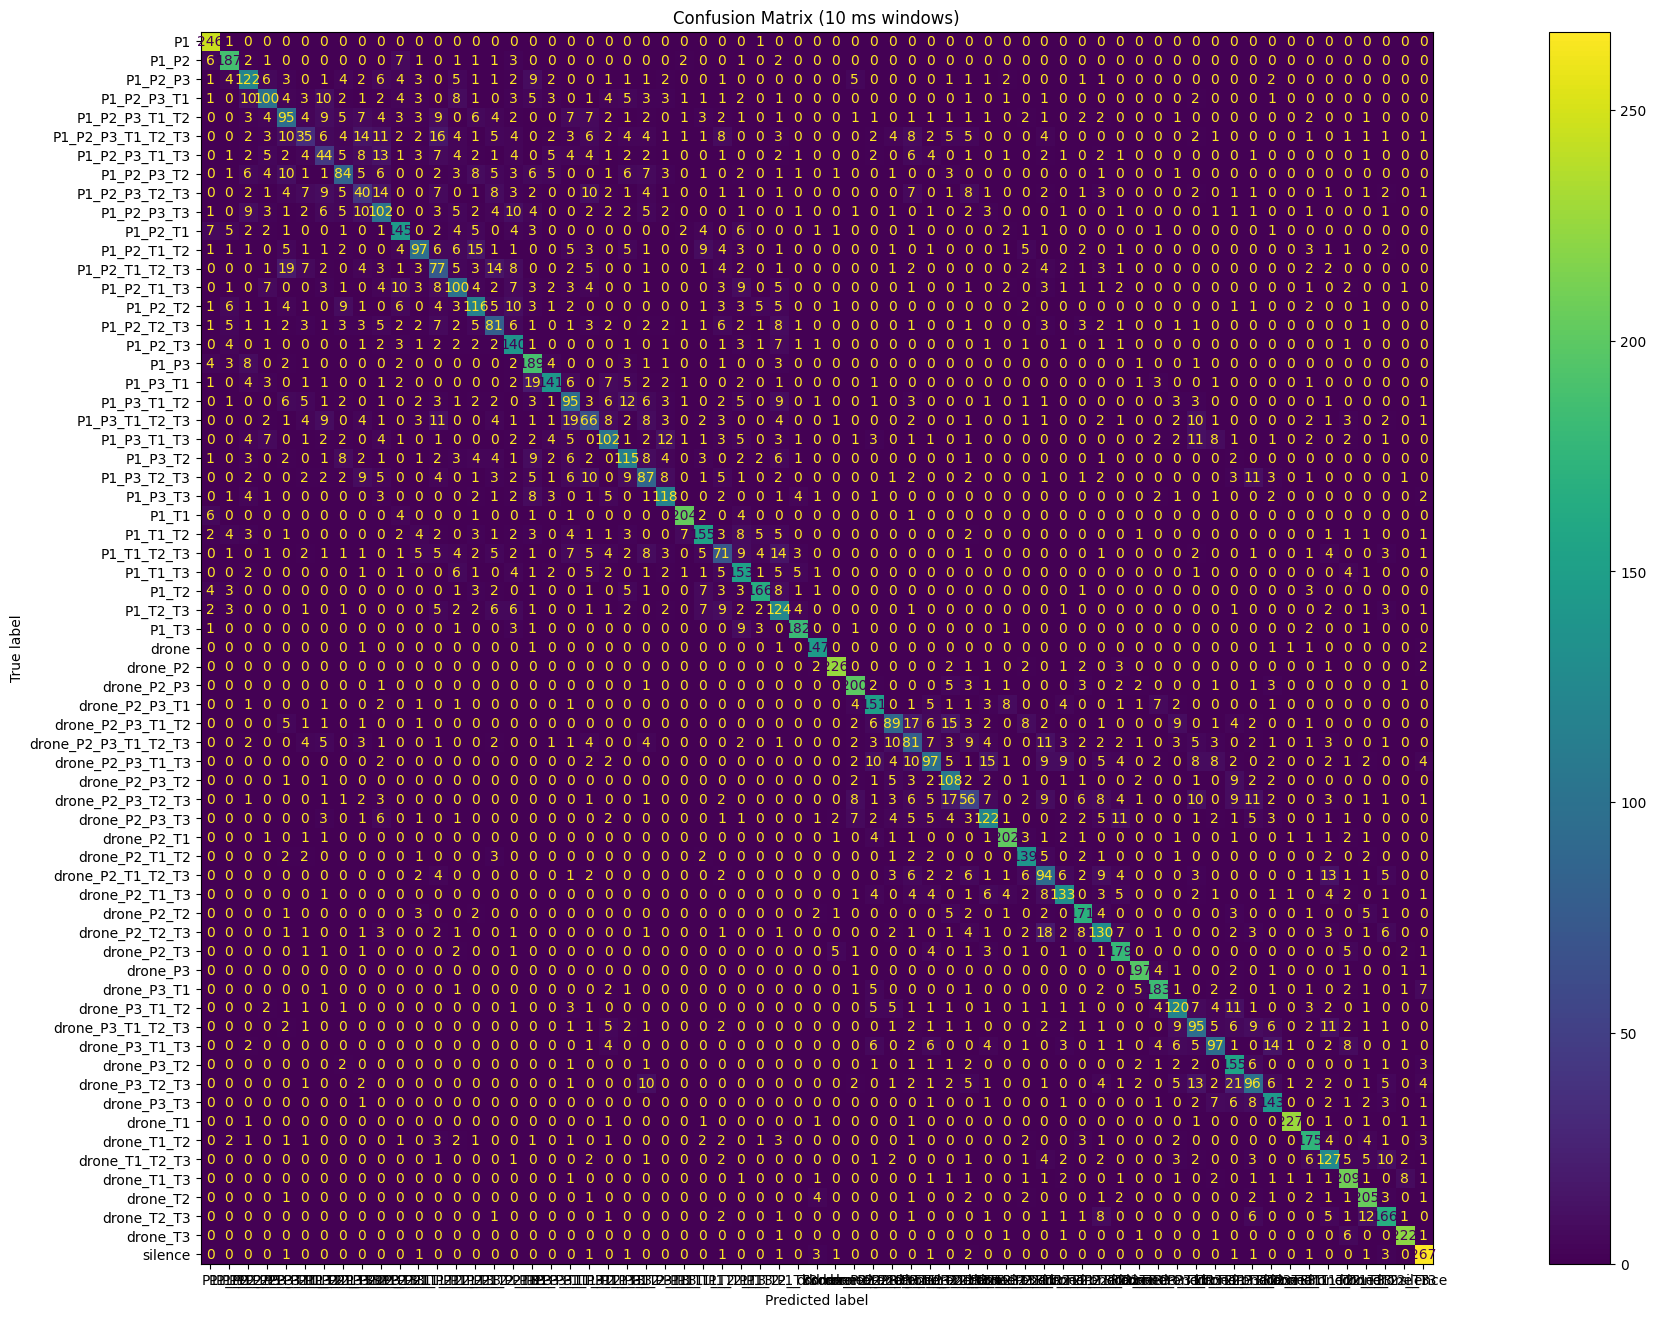

In [17]:

#confuse matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(30, 16))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=decoded_class_names
)
disp.plot(ax=ax)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (10 ms windows)")
plt.show()